# Imports

In [1]:
# standard library
import os
import uuid
import json
import math

# third party libraries
import cv2
import torch
import numpy as np
from tqdm import tqdm
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torch.utils.flop_counter import FlopCounterMode
from torch.utils.data import Dataset, DataLoader, random_split


In [2]:
batch_size = 8
os.makedirs('figures', exist_ok=True)
NUM_GRID_CELLS = 7
image_size = 448
device = 'cuda'
train_split = 0.9
test_split = val_loss = (1 - train_split) / 2

In [3]:
seed = 1111

# NumPy
np.random.seed(seed)

# PyTorch
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Model

In [4]:
'''
This block models the skip connection introduced in the Resnet paper 2015.
'''

class ResnetBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=output_channels, out_channels=output_channels, kernel_size=3, stride=2, padding=1)
        self.downsamp_conv = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.downsamp_bn = nn.BatchNorm2d(output_channels)
        
    def forward(self, x):
        # feature extraction
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # reduce H and W by 2
        out = self.conv2(out)
        out = self.bn2(out)
        
        # bring x to required number of channels
        downsamp_x = self.downsamp_conv(x)
        downsamp_x = self.downsamp_bn(downsamp_x)
        
        # skip connection
        return self.relu(out + downsamp_x)

In [5]:
'''
Simple 1x1 convolution block, nothing much to see here.
'''

class ConvBlock(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=1, padding=0, activation=True):
        super().__init__()
        
        self.channel_downsamp_conv = nn.Conv2d(in_channels=input_channels, out_channels=output_channels, kernel_size=kernel_size, padding=padding)
        self.channel_downsamp_bn = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU()
        self.activation = activation
        
    def forward(self, x):
        out = self.channel_downsamp_conv(x)
        out = self.channel_downsamp_bn(out)
        if self.activation:
            out = self.relu(out)
        
        return out

In [6]:
'''
LOCALS model architecture.
The localisation and classification tasks are separated and given to separate heads
'''

class LOCALS(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            ConvBlock(input_channels=3, output_channels=16, kernel_size=3, padding=1), # 448
            ResnetBlock(input_channels=16, output_channels=32), # 224
            ResnetBlock(input_channels=32, output_channels=64), # 112
            ResnetBlock(input_channels=64, output_channels=128), # 56
            ResnetBlock(input_channels=128, output_channels=256), # 28
            ResnetBlock(input_channels=256, output_channels=512), # 14
            ResnetBlock(input_channels=512, output_channels=256), # 7
        )
        
        # 1x1 conv is important here because we do not want to do feature extraction in heads
        
        self.loc_head = nn.Sequential(
            ConvBlock(input_channels=256, output_channels=64),
            ConvBlock(input_channels=64, output_channels=16),
            ConvBlock(input_channels=16, output_channels=2, activation=False),
        )
        
        self.class_head = nn.Sequential(
            ConvBlock(input_channels=256, output_channels=1, activation=False),
        )
        
    def forward(self, x):
        out =  self.model(x)
        loc_info = self.loc_head(out) # [B, 2, 7, 7]
        class_info = self.class_head(out) # [B, 1, 7, 7]
        out = torch.concatenate([loc_info, class_info], dim=1) # [B, 3, 7, 7]
        out = out.permute(0, 2, 3, 1) # [B, 7, 7, 3]
        out = torch.sigmoid(out)
        return out

# Dataset

In [7]:
class Pencils(Dataset):
    def __init__(self, image_list, images_dir, numpy_dump_dir):
        self.image_list = image_list # contains the image names
        self.images_dir = images_dir
        self.numpy_dump_dir = numpy_dump_dir # contains the directory names in which labels are

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_name = self.image_list[idx]

        image = cv2.imread(
            os.path.join(self.images_dir,
                         image_name)
        )
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # cv2 loads in BGR format by default so convert to RGB

        image = cv2.resize(image, (image_size, image_size))
        image = image.astype(np.float32) / 255.0
        image = torch.from_numpy(image).permute(2, 0, 1) # convert from [H, W, C] to [C, H, W] (PyTorch format)

        prefix = image_name.split('.')[0]
        annotation_matrix = np.load(os.path.join(self.numpy_dump_dir, f'{prefix}.npy')) # load the equivalent label

        return image, annotation_matrix

In [8]:
dataset = torch.load('locals-for-pencils-dataset.pt')

N = len(dataset)
train_size = int(train_split * N)
test_size = int(N * test_split)
val_size = N - (train_size + test_size)

print(f'Total Size: {N}, Train Size: {train_size}, Test Size: {test_size}, Val Size: {val_size}')

train_dataset, test_dataset, val_dataset = random_split(
    dataset,
    [train_size, test_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=True,
    pin_memory=True
)

Total Size: 499, Train Size: 449, Test Size: 24, Val Size: 26


C:\Users\agile\AppData\Local\Temp\ipykernel_23372\162094761.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load('locals-for-pencils-dataset.pt')


In [9]:
# hello world forward pass to check if everything is working

model = LOCALS()
model.eval()
with torch.no_grad():
    for images, labels in train_loader:
        print(model(images).shape)
        break

torch.Size([8, 7, 7, 3])


# Dataset Visiualization

In [10]:
def closest_factors(n):
    d = math.isqrt(n)  # integer sqrt
    while n % d != 0:
        d -= 1
    return d, n // d

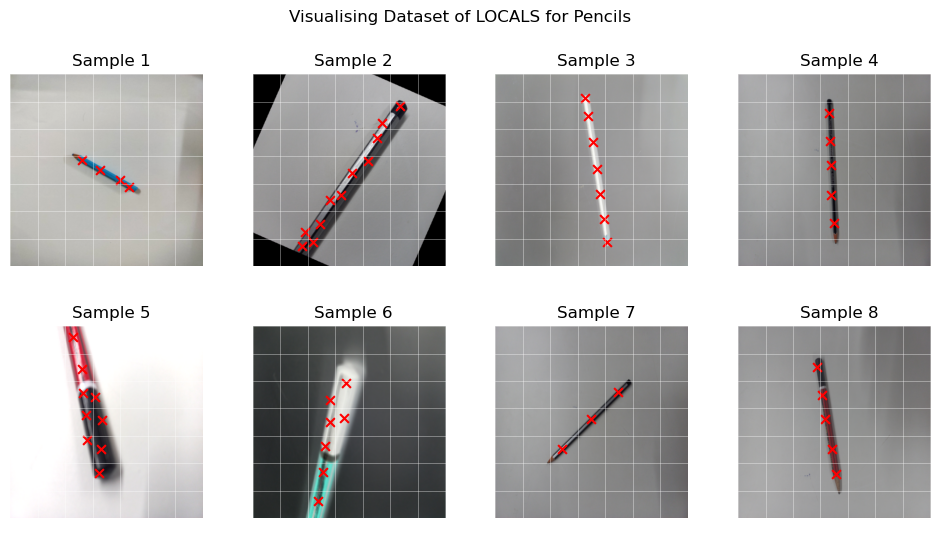

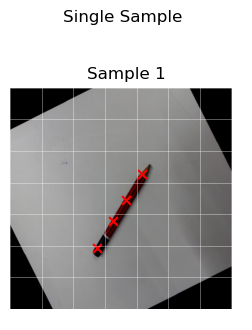

In [11]:
def visuaize_dataset(dataloader, num_images, plot_title=None):
    rows, cols = closest_factors(num_images)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, max(3 * rows, 4)), squeeze=False)
    fig.suptitle('Visualising Dataset of LOCALS for Pencils') if not plot_title else fig.suptitle(plot_title)
    image_idx = 0
    axes = axes.flatten()
    
    for images, labels in dataloader:
        if image_idx >= num_images: break
        for i, image in enumerate(images):
            if image_idx >= num_images: break
            image_plt = image.permute(1, 2, 0)
            ax = axes[i]
            
            ax.axis('off')
            label = labels[i]
            ax.set_title(f'Sample {image_idx + 1}')
            ax.imshow(image_plt)
            
            grid_size = image_size / NUM_GRID_CELLS
            for g in range(NUM_GRID_CELLS + 1):
                pos = g * grid_size
                
                # vertical lines
                ax.axvline(
                    x=pos,
                    color='white',
                    linewidth=0.5,
                    alpha=0.5
                )

                # horizontal lines
                ax.axhline(
                    y=pos,
                    color='white',
                    linewidth=0.5,
                    alpha=0.5
                )
            
            for j in range(NUM_GRID_CELLS):
                for k in range(NUM_GRID_CELLS):
                    xnb, ynb, c = label[j][k]
                    if c < 0.5:
                        continue
                    x = ((k / NUM_GRID_CELLS) + (xnb * (1 / NUM_GRID_CELLS))) * image_size
                    y = ((j / NUM_GRID_CELLS) + (ynb * (1 / NUM_GRID_CELLS))) * image_size
                    
                    ax.scatter(x, y, color='red', marker='x', s=40)
            image_idx += 1
    
    plt.savefig('figures/visualised_dataset.png', dpi=300, bbox_inches='tight') if not plot_title else \
        plt.savefig(f"figures/visualised_dataset_{plot_title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

visuaize_dataset(train_loader, 8)
visuaize_dataset(train_loader, 1, plot_title='Single Sample')

In [12]:
def visualize_predictions(model, dataloader, num_images, plot_title=None):
    model.eval()

    with torch.no_grad():
        rows, cols = closest_factors(num_images)
        fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3 * cols, 3 * rows + 1),
        squeeze=False
    )
        fig.suptitle('Visualising Predictions of LOCALS for Pencils') if not plot_title else fig.suptitle(plot_title)
        axes = axes.flatten()
        image_idx = 0
        
        for images, labels in dataloader:
            if image_idx >= num_images: break
            outputs = model(images.to(device))
            for i, image in enumerate(images):
                image_plt = image.permute(1, 2, 0)
                label = labels[i]
                output = outputs[i].detach().cpu()
                ax = axes[image_idx]
                ax.axis('off')
                ax.imshow(image_plt.detach().cpu())
                ax.set_title(f'Prediction {image_idx + 1}')
                grid_size = image_size / NUM_GRID_CELLS
                
                for g in range(NUM_GRID_CELLS + 1):
                    pos = g * grid_size
                    
                    # vertical lines
                    ax.axvline(
                        x=pos,
                        color='white',
                        linewidth=0.5,
                        alpha=0.5
                    )

                    # horizontal lines
                    ax.axhline(
                        y=pos,
                        color='white',
                        linewidth=0.5,
                        alpha=0.5
                    )

                for j in range(NUM_GRID_CELLS):
                    for k in range(NUM_GRID_CELLS):
                        
                        # ground truth
                        xnb, ynb, c = label[j][k]

                        if c.item() > 0.5:

                            x = ((k / NUM_GRID_CELLS) + (xnb * (1 / NUM_GRID_CELLS))) * image_size
                            y = ((j / NUM_GRID_CELLS) + (ynb * (1 / NUM_GRID_CELLS))) * image_size
                            ax.scatter(
                                x.detach().cpu(),
                                y.detach().cpu(),
                                color='yellow',
                                marker='x',
                                s=40,
                                alpha=1
                            )

                        # prediction
                        pxnb, pynb, pc = output[j][k]

                        if pc.item() >= 0.5:

                            x = ((k / NUM_GRID_CELLS) + (pxnb * (1 / NUM_GRID_CELLS))) * image_size
                            y = ((j / NUM_GRID_CELLS) + (pynb * (1 / NUM_GRID_CELLS))) * image_size

                            ax.scatter(
                                x.detach().cpu(),
                                y.detach().cpu(),
                                color='red',
                                marker='x',
                                s=40,
                                alpha=0.5,
                            )
                            
                            ax.text(
                                x.detach().cpu() + 5, # x offset
                                y.detach().cpu() + 5, # y offset
                                f'{pc.detach().cpu():.2f}',
                                color='white',
                                fontsize=10
                            )
                
                image_idx += 1
                
        
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.savefig(f"figures/visualised_predictions_{plot_title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches='tight') if plot_title else \
            plt.savefig(f'figures/visualised_predictions.png')
        plt.show()

# Loss Function

In [13]:
def locals_loss(beta=1.0, gamma=5.0):  
    '''
    beta: weight for localization loss
    gamma: weight for objectness loss
    '''
    
    def binary_focal_loss(pred, target, alpha=0.25, gamma=2.0, eps=1e-8):
        '''
        pred: predicted probabilities (after sigmoid)
        target: ground truth (0 or 1)
        alpha: weighting factor for class imbalance
        gamma: focusing parameter for hard examples
        '''
        pred = pred.clamp(eps, 1.0 - eps)  # avoid log(0)
        pt = pred * target + (1 - pred) * (1 - target)
        loss = - alpha * (1 - pt) ** gamma * (target * torch.log(pred) + (1 - target) * torch.log(1 - pred))
        return loss.mean()

    def focal_localization_loss(pred_coords, true_coords, mask, alpha=0.25, gamma=2.0, eps=1e-8):
        d = torch.sqrt(torch.sum((pred_coords - true_coords) ** 2, dim=-1))
        pt = 1 - torch.sigmoid(20 * (d - 0.1))
        pt = pt.clamp(eps, 1.0 - eps)
        loss = - alpha * (1 - pt) ** gamma * mask * torch.log(pt)
        if mask.sum() == 0:
            return 0
        
        return (loss).sum() / mask.sum()
        
    # actual loss function
    def loss_func(predicted, true):
        # goal is to sum each loss for each prediction in each batch
        loc_loss = 0
        obj_loss = 0
        
        # iterate through each image in the batch
        for i in range(true.shape[0]):
            ith_predicted = predicted[i]
            ith_true = true[i]

            obj_mask = ith_true[..., 2]
            true_coordinates = ith_true[..., :2]

            obj_pred = ith_predicted[..., 2]
            pred_coordinates = ith_predicted[..., :2]

            # find localization loss
            loc_loss += focal_localization_loss(pred_coordinates, true_coordinates, obj_mask)
            
            # find objectness loss
            ith_obj_loss = binary_focal_loss(obj_pred, obj_mask)
            obj_loss += ith_obj_loss

        # first find mean loss
        loc_loss /= true.shape[0]
        obj_loss /= true.shape[0]

        # then find total loss
        total_loss = beta * loc_loss + gamma * obj_loss
        return total_loss

    return loss_func

# Training

In [14]:
# model, optimizer, and custom loss
model = LOCALS()
model.to(device)

optimizer = Adam(model.parameters(), lr=1e-3)
criterion = locals_loss()

# training parameters
num_epochs = 50
loss_ot = [] # loss overtime
min_val_loss = float('inf')

In [15]:
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for inputs, targets in pbar:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        total_val_loss = 0

        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(test_loader)
    
    # if val loss is best seen save the model
    if avg_val_loss < min_val_loss:
        min_val_loss = avg_val_loss
        torch.save(model.state_dict(), "locals-for-pencils-model.pth")
    
    print(f"Epoch {epoch+1}: Avg Training Loss = {avg_loss}, Avg Val Loss = {avg_val_loss}")
    loss_ot.append(avg_loss)

Epoch 1/50: 100%|██████████| 57/57 [00:10<00:00,  5.24it/s]


Epoch 1: Avg Training Loss = 0.4993810909382921, Avg Val Loss = 0.41967482123127603


Epoch 2/50: 100%|██████████| 57/57 [00:09<00:00,  5.85it/s]


Epoch 2: Avg Training Loss = 0.25104846882843684, Avg Val Loss = 0.6641629125496377


Epoch 3/50: 100%|██████████| 57/57 [00:09<00:00,  5.81it/s]


...

Epoch 48: Avg Training Loss = 0.022490270838101806, Avg Val Loss = 0.12584101233979927


Epoch 49/50: 100%|██████████| 57/57 [00:10<00:00,  5.58it/s]


Epoch 49: Avg Training Loss = 0.0175051911299587, Avg Val Loss = 0.12834142061558326


Epoch 50/50: 100%|██████████| 57/57 [00:09<00:00,  5.78it/s]


Epoch 50: Avg Training Loss = 0.017932494951282043, Avg Val Loss = 0.12908238796176694


# Graphing Loss

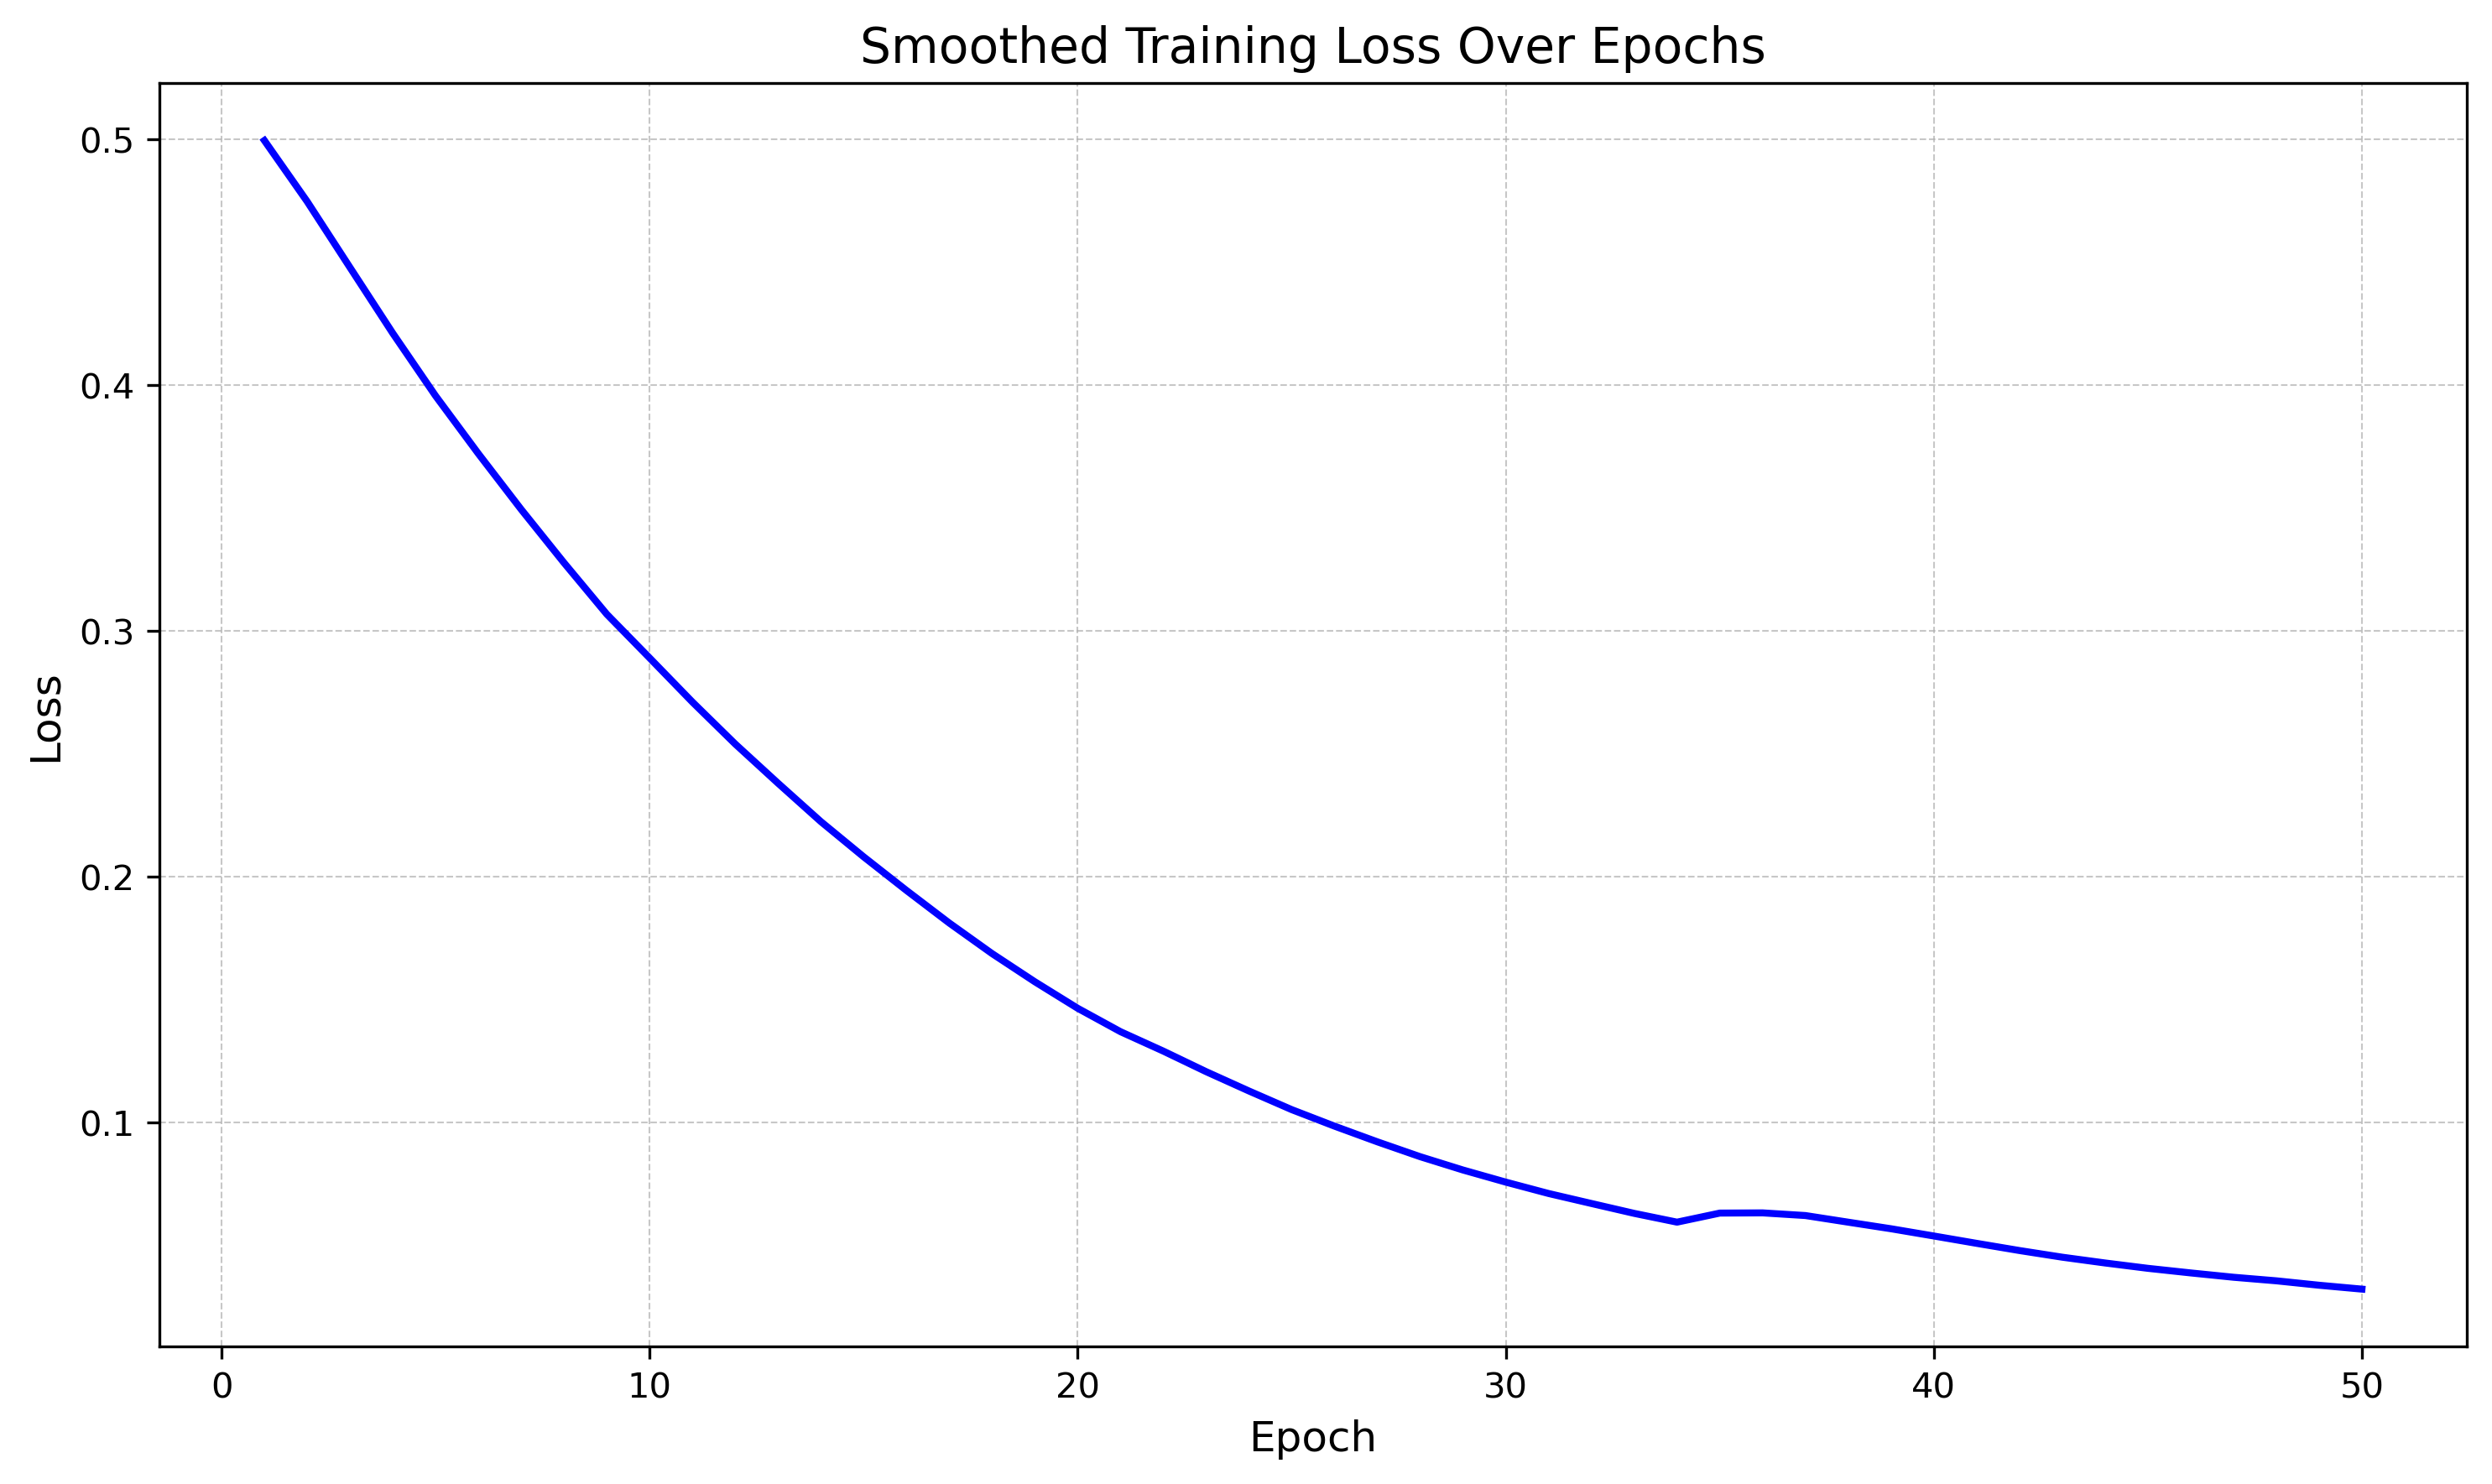

In [16]:
def smooth_curve(points, factor=0.9):
    # applies exponential smoothing to a curve
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

# extract raw loss and val_loss from history
loss = loss_ot
val_loss = None

# smooth the losses
smooth_loss = smooth_curve(loss)
smooth_val_loss = smooth_curve(val_loss) if val_loss is not None else None

# plot the smoothed losses
epochs = range(1, len(smooth_loss) + 1)
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(epochs, smooth_loss, color='blue', linewidth=2)
plt.title(r'Smoothed Training Loss Over Epochs', fontsize=14)
plt.xlabel(r'Epoch', fontsize=12)
plt.ylabel(r'Loss', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("figures/smoothed_training_loss.png", dpi=300)
plt.show()

# Testing

In [17]:
model = LOCALS()
model.to(device)
model.load_state_dict(torch.load("locals-for-pencils-model.pth"))
model.eval()

C:\Users\agile\AppData\Local\Temp\ipykernel_23372\695279281.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("locals-for-pencils-model.pt

LOCALS(
  (model): Sequential(
    (0): ConvBlock(
      (channel_downsamp_conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (channel_downsamp_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): ResnetBlock(
      (conv1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (downsamp_conv): Conv2d(16, 32, kernel_size=(2, 2), stride=(2, 2))
      (relu): ReLU()
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsamp_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ResnetBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(

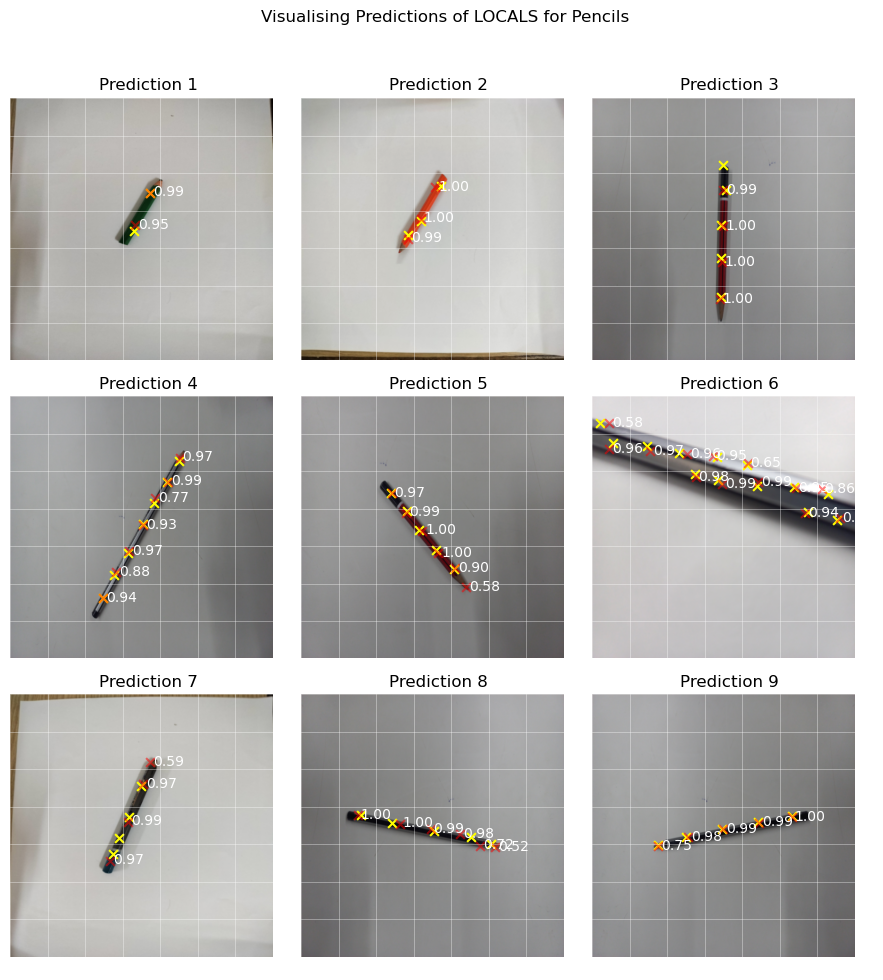

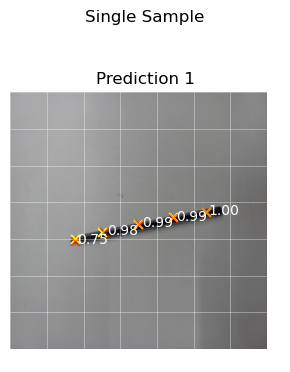

In [18]:
visualize_predictions(model, test_loader, 9)
visualize_predictions(model, test_loader, 1, plot_title='Single Sample')

# Evaluation

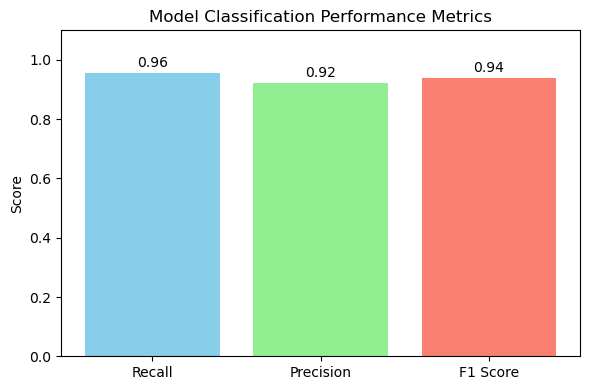

Recall: 0.9555555555555556
Precision: 0.9214285714285714
F1 Score: 0.9381818181818182


In [19]:
def find_recall_precision_f1_score(model, dataloader, threshold=0.5, num_batches=100):
    model.eval()
    
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break
            
            images_tensor = images.to(device)
            predictions_batch = model(images_tensor) # [B, 7, 7, 3]
            batch_size = images_tensor.shape[0]
            
            for i in range(batch_size):
                prediction = predictions_batch[i]
                prediction = prediction.cpu().numpy()
                
                label = labels[i]
                label_numpy = label.cpu().numpy()
                
                # compare predictions vs labels
                for j in range(7):
                    for k in range(7):
                        pred_obj = prediction[j, k, -1]
                        label_obj = label_numpy[j, k, -1]
                        
                        if pred_obj > threshold and label_obj > 0:
                            true_positives += 1
                        elif pred_obj > threshold and label_obj == 0:
                            false_positives += 1
                        elif pred_obj <= threshold and label_obj > 0:
                            false_negatives += 1
    
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = ['Recall', 'Precision', 'F1 Score']
    values = [recall, precision, f1_score]

    plt.figure(figsize=(6, 4))
    plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon'])
    plt.ylim(0, 1.1)
    plt.title('Model Classification Performance Metrics')
    plt.ylabel('Score')
    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.tight_layout()
    plt.savefig("figures/recall-precision-f1score.png", dpi=300)
    plt.show()
    
    return recall, precision, f1_score

recall, precision, f1_score = find_recall_precision_f1_score(model, test_loader, num_batches=100)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1_score)

In [20]:
def find_mAP_hard2(dataloader, class_threshold, model):
    model.eval()
    dist_thresholds = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    APs = []
    
    for dist_threshold in dist_thresholds:
        all_detections = []
        num_trues = 0
        for batched_images, batched_labels in dataloader:
            batched_images = batched_images.to(device)
            batched_predictions = model(batched_images).detach().cpu()
            batch_size = batched_images.shape[0]
            
            for b in range(batch_size):
                predictions = batched_predictions[b]
                labels = batched_labels[b]
                
                predictions = predictions.reshape(-1, predictions.shape[-1])
                trues = labels.reshape(-1, labels.shape[-1])
                taken_trues = [False] * trues.shape[0]

                num_trues += torch.sum(trues[:, 2] == 1).item()
                indices = torch.arange(predictions.shape[0])
                order = predictions[:, -1].argsort(descending=True)
                predictions = predictions[order]
                indices = indices[order]
                
                for i in range(predictions.shape[0]):
                    pred_xnb, pred_ynb, pred_conf = predictions[i]
                    cell_idx = indices[i]
                    row = cell_idx // NUM_GRID_CELLS
                    col = cell_idx % NUM_GRID_CELLS
                    pred_x = ((col / NUM_GRID_CELLS) + (pred_xnb * (1 / NUM_GRID_CELLS)))
                    pred_y = ((row / NUM_GRID_CELLS) + (pred_ynb * (1 / NUM_GRID_CELLS)))
                    
                    if pred_conf >= class_threshold:
                        closest_idx = -1
                        closest_distance = torch.inf
                        for j in range(trues.shape[0]):
                            true_xnb, true_ynb, true_conf = trues[j]
                            row = j // NUM_GRID_CELLS
                            col = j % NUM_GRID_CELLS
                            true_x = ((col / NUM_GRID_CELLS) + (true_xnb * (1 / NUM_GRID_CELLS)))
                            true_y = ((row / NUM_GRID_CELLS) + (true_ynb * (1 / NUM_GRID_CELLS)))
                            
                            if true_conf >= 0.5:
                                pred_coord = torch.tensor([pred_x, pred_y])
                                true_coord = torch.tensor([true_x, true_y])
                
                                dist = torch.sqrt(torch.sum((pred_coord - true_coord) ** 2, dim=-1))
                                if dist < closest_distance:
                                    closest_distance = dist
                                    closest_idx = j
                        
                        dist_conf = 1 - torch.sigmoid(69 * (closest_distance - 0.1))
                        if closest_idx != -1 and not taken_trues[closest_idx] and dist_conf >= dist_threshold:
                            taken_trues[closest_idx] = True
                            all_detections.append((pred_conf.item(), 1, 0))
                        else:
                            all_detections.append((pred_conf.item(), 0, 1))
    
        all_detections.sort(key=lambda x: x[0], reverse=True)
        TP = [d[1] for d in all_detections]
        FP = [d[2] for d in all_detections]
        
        TP_cum = np.cumsum(TP)
        FP_cum = np.cumsum(FP)

        precisions = TP_cum / (TP_cum + FP_cum + 1e-6)
        recalls = TP_cum / (num_trues + 1e-6)
        AP = np.trapezoid(precisions, recalls)
        APs.append(AP)
    
    return sum(APs)/len(APs)

mAP = find_mAP_hard2(test_loader, 0.5, model)
print(f'mAP of LOCALS for Pencils is: {mAP}')

mAP of LOCALS for Pencils is: 0.9572623174551186


In [21]:
# function that calculates the pearson correlation coefficient given a list of points
def pearson_corr(points):
    points_array = np.array(points)

    x = points_array[:, 0]
    y = points_array[:, 1]

    corr = np.corrcoef(x, y)[0, 1]
    return corr

# function that calculates the mCS value mentioned in the paper
def find_mCS(model, dataloader, threshold=0.5, num_batches=100):
    correlations = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            if batch_idx >= num_batches:
                break

            images_tensor = images.to(device)

            predictions_batch = model(images_tensor)
            batch_size = images_tensor.shape[0]

            for i in range(batch_size):
                prediction = predictions_batch[i]
                prediction = prediction.cpu().numpy()

                label = labels[i]

                # extract predicted points
                predicted_points = []
                for row in range(prediction.shape[0]):
                    for col in range(prediction.shape[1]):
                        cell = prediction[row][col]
                        if cell[-1] > threshold:
                            xnb, ynb, c = cell
                            xn = ((col / NUM_GRID_CELLS) + (xnb * (1 / NUM_GRID_CELLS)))
                            yn = ((row / NUM_GRID_CELLS) + (ynb * (1 / NUM_GRID_CELLS)))
                            predicted_points.append([xn, yn])

                # extract label points
                label_points = []
                for row in range(label.shape[0]):
                    for col in range(label.shape[1]):
                        cell = label[row][col]
                        if cell[-1] > 0:
                            xnb, ynb, c = cell
                            xn = ((col / NUM_GRID_CELLS) + (xnb * (1 / NUM_GRID_CELLS)))
                            yn = ((row / NUM_GRID_CELLS) + (ynb * (1 / NUM_GRID_CELLS)))
                            label_points.append([xn, yn])

                if not predicted_points:
                    correlations.append(0)
                else:
                    correlations.append(abs(pearson_corr(label_points + predicted_points)))

    return np.mean(correlations) if correlations else 0.0

mCS = find_mCS(model, test_loader, num_batches=100)
print("Mean Correlation Score:", mCS * 100, "%")

Mean Correlation Score: 96.19295981218558 %


# Saving Run Details

In [22]:
def save_run_metrics(seed, train_split, test_split, recall, precision, f1_score, mAP, mCS):
    run_id = str(uuid.uuid4())
    run_data = {
        'seed': seed,
        'run_id': run_id,
        'train_split': train_split,
        'test_split': test_split,
        'classification_performance': {
            'recall': recall,
            'precision': precision,
            'f1_score': f1_score
        },
        'overall_performance': {
            'mean_average_precision': mAP,
            'mean_correlation_score': mCS
        }
    }
    
    with open(f'run_metrics_{run_id}.json', 'w') as run_metrics_file:
        json.dump(run_data, run_metrics_file)

execute_save_run_metrics = False
if execute_save_run_metrics:
    save_run_metrics(seed, train_split, test_split, recall, precision, f1_score, mAP, mCS)

# Visualising What the Model Sees

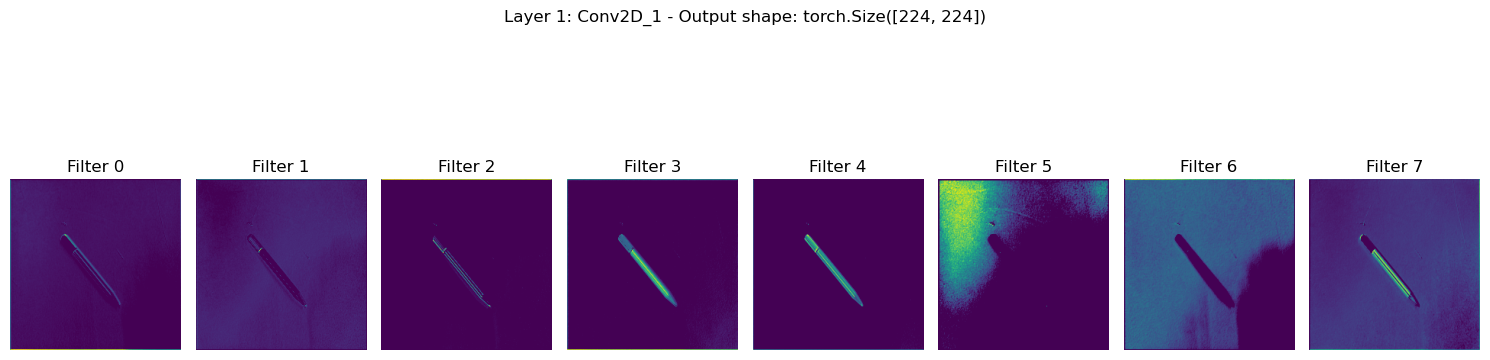

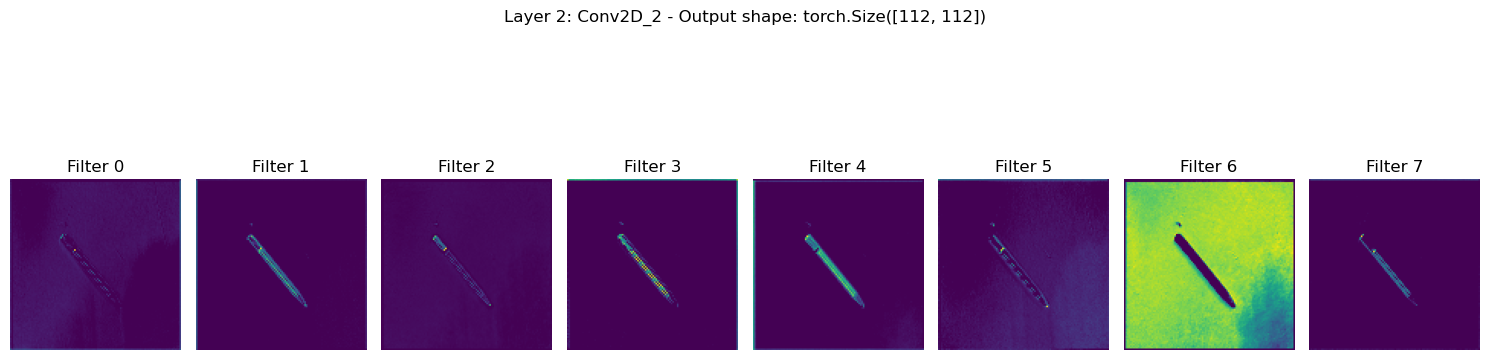

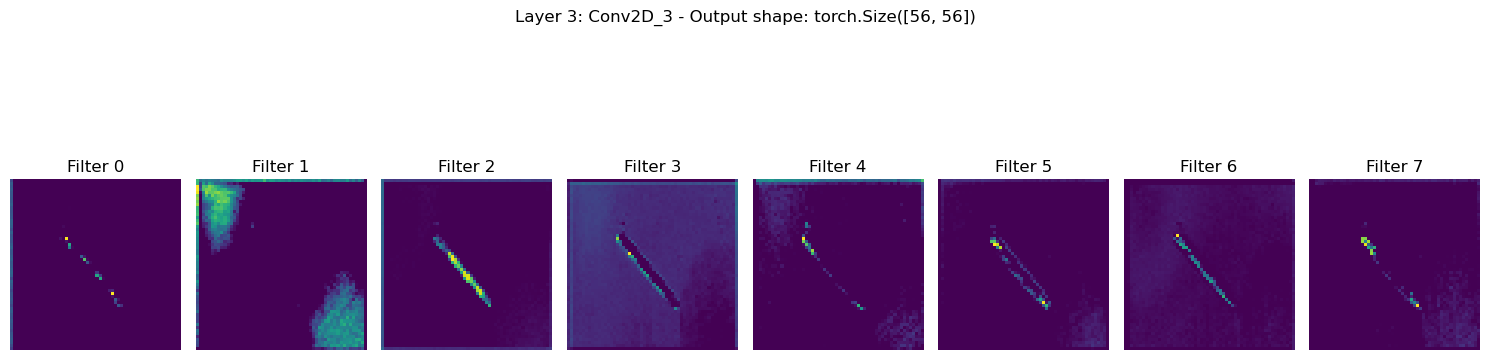

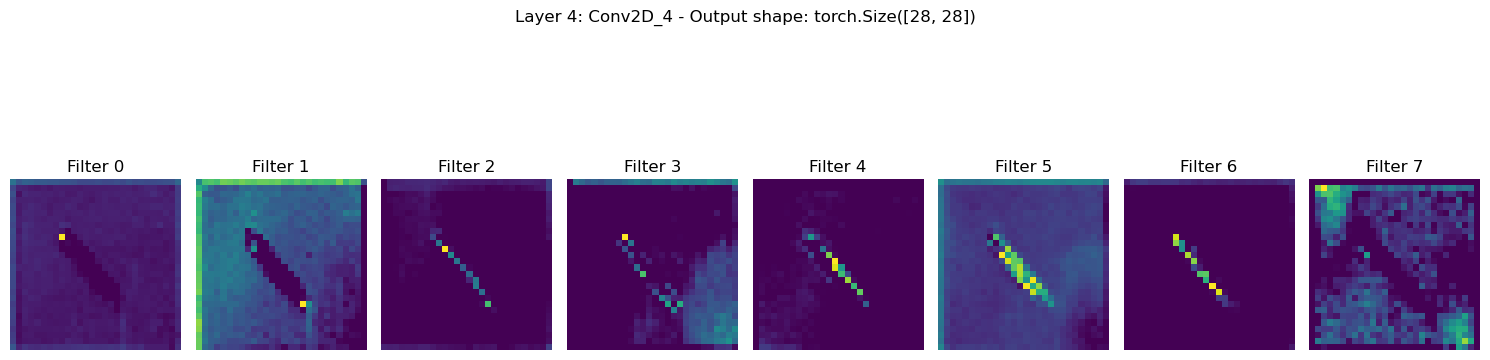

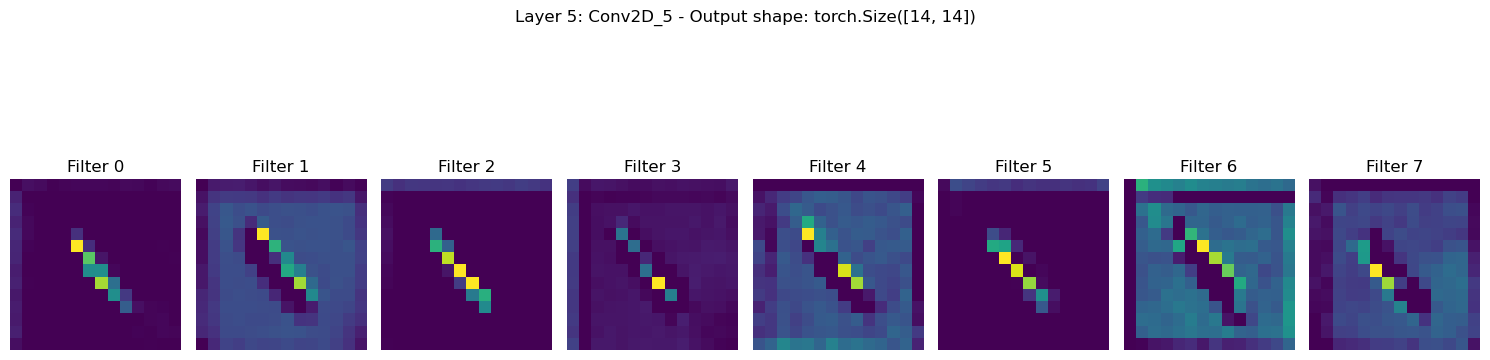

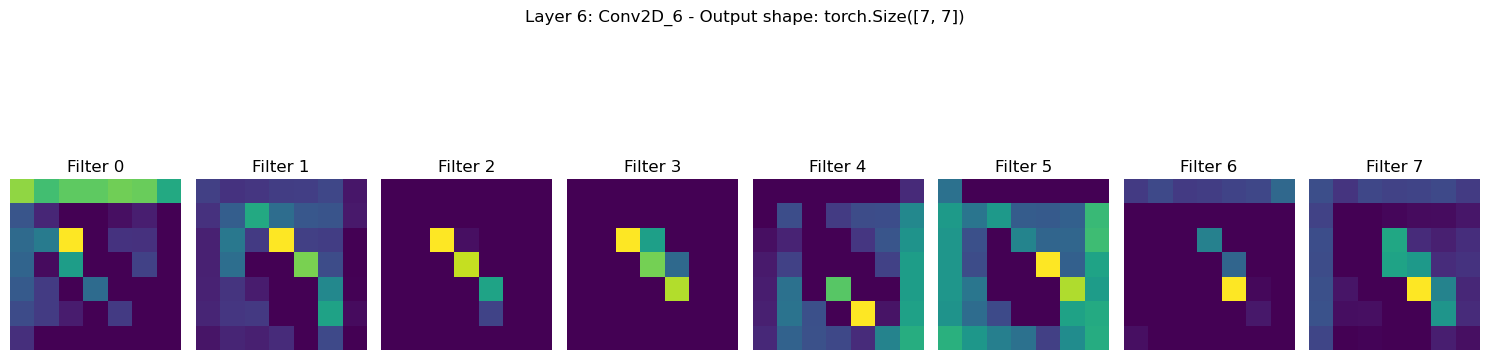

In [23]:
def visualise_intermediates(dataloader, model):
    # list of indeces of Conv2D layers in model
    conv_indices = [0, 4, 8, 11, 15, 18, 21]

    # get a single batch from the dataloader
    for batch_idx, (images, labels) in enumerate(dataloader):
        if batch_idx == 0:  # take first batch
            # take only the first image in the batch
            image_tensor = images[0].to(device).unsqueeze(0) # [1, C, H, W]
            break

    feature_extractor = list(model.children())[0]
    conv_indices = [1, 2, 3, 4, 5, 6]

    # extract only the feature extractor layers
    model.eval()
    feature_extractor_layers = list(feature_extractor.children())

    # visualize conv layer outputs
    for i, idx in enumerate(conv_indices):
        x = image_tensor.clone()
        for layer in feature_extractor_layers[:idx + 1]:
            x = layer(x)

        feature_maps = x.detach().cpu().squeeze(0) # [C, H, W]
        n_filters = min(8, feature_maps.shape[0])

        fig, axs = plt.subplots(1, n_filters, figsize=(15, 5))
        fig.suptitle(f"Layer {i+1}: Conv2D_{idx} - Output shape: {feature_maps.shape[1:]}")

        for j in range(n_filters):
            axs[j].imshow(feature_maps[j].numpy(), cmap='viridis')
            axs[j].axis('off')
            axs[j].set_title(f"Filter {j}")

        if idx == 2:
            plt.savefig("figures/Figure 6.png", dpi=600, bbox_inches="tight", pad_inches=0, format="png")
        if idx == 3:
            plt.savefig("figures/Figure 7.png", dpi=600, bbox_inches="tight", pad_inches=0, format="png")
        
        plt.tight_layout()
        plt.show()
    
visualise_intermediates(test_loader, model)

# Seeing Number of Parameters, FLOPs

In [24]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 7,735,769


In [25]:
flop_counter = FlopCounterMode(display=True)

with flop_counter:
    for images, labels in test_loader:
        outputs = model(images.to(device))
        break

Module                 FLOP    % Total
------------------  -------  ---------
LOCALS              15.647B    100.00%
- aten.convolution  15.647B    100.00%
LOCALS.class_head    0.000B      0.00%
- aten.convolution   0.000B      0.00%
LOCALS.loc_head      0.002B      0.01%
- aten.convolution   0.002B      0.01%
LOCALS.model        15.645B     99.99%
- aten.convolution  15.645B     99.99%
